In [ ]:
from scipy.stats import pearsonr
import numpy as np

In [ ]:
a = np.random.normal(size=10)
b = np.random.normal(size=10)

In [ ]:
b

array([-1.20069958, -0.14763735,  1.47887901, -0.43189655,  0.24634418,
       -0.99107358,  0.34694897,  0.05132718, -0.25682586, -0.42926324])

In [ ]:
from scipy.stats import spearmanr

In [ ]:
pearsonr(a,b)

PearsonRResult(statistic=np.float64(0.17618257333708096), pvalue=np.float64(0.6263423800350506))

In [ ]:
spearmanr(a,b)

SignificanceResult(statistic=np.float64(-0.2727272727272727), pvalue=np.float64(0.44583834154275137))

In [ ]:
from scipy.stats import kendalltau

In [ ]:
kendalltau(a,b)

SignificanceResult(statistic=np.float64(-0.28888888888888886), pvalue=np.float64(0.2912483465608466))

# Credit card Default prediction EDA

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
pd.set_option('display.max_columns', 300) #Setting column display limit
plt.style.use('ggplot') #Applying style to graphs

In [ ]:
df1 = pd.read_csv(r"/content/application_data.csv")

df1 -> Current application Data set
  

In [ ]:
df1.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,Laborers,1.0,2.0,2.0,WEDNESDAY,10.0,0.0,0.0,0.0,0.0,0.0,0.0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,Core staff,2.0,1.0,1.0,MONDAY,11.0,0.0,0.0,0.0,0.0,0.0,0.0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531.0,26.0,1.0,1.0,1.0,1.0,1.0,0.0,Laborers,1.0,2.0,2.0,MONDAY,9.0,0.0,0

In [ ]:
df1.shape

(40782, 122)

In [ ]:
df1.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40782 entries, 0 to 40781
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS

In [ ]:
df1.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,40782.00000,40782.000000,40782.000000,4.078200e+04,4.078200e+04,40782.000000,4.075100e+04,40782.000000,40782.000000,40782.000000,40782.000000,40781.000000,13907.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,17779.000000,4.068000e+04,32693.000000,20075.000000,16946.000000,20866.000000,13618.000000,12195.000000,19022.000000,20224.000000,20494.000000,13092.000000,16494.000000,12825.000000,20253.000000,12434.000000,18306.000000,20075.000000,16946.000000,20866.000000,13618.000000,12195.000000,19022.000000,20224.000000,20494.000000,13092.000000,16494.000000,12825.000000,20253.000000,12434.000000,18306.000000,20075.000000,16946.000000,20866.000000,13618.000000,12195.000000,19022.000000,20224.000000,20494.000000,13092.000000,16494.000000,12825.000000,20253.000000,12434.000000,18306.000000,21079.000000,40643.000000,40643.000000,40643.000000,40643.000000,40780.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.0,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,40781.000000,35280.000000,35280.000000,35280.000000,35280.000000,35280.000000,35280.000000
mean,123690.76470,0.080894,0.418984,1.710366e+05,5.989910e+05,27113.590297,5.382323e+05,0.020756,-16026.746555,63694.420529,-4972.378598,-2992.598416,12.065003,0.999975,0.820161,0.199112,0.997891,0.277654,0.054756,2.158481,2.051862,2.031436,12.057429,0.015571,0.049925,0.039381,0.080381,0.231946,0.178686,0.502586,5.134345e-01,0.511965,0.117296,0.088947,0.978525,0.751601,0.044770,0.078145,0.150232,0.225261,0.231730,0.066292,0.100273,0.107265,0.008806,0.028548,0.114044,0.088132,0.977889,0.758854,0.042595,0.073695,0.145843,0.221273,0.228287,0.064830,0.105110,0.105775,0.007962,0.027335,0.117774,0.088599,0.978536,0.754901,0.044706,0.077430,0.149808,0.224870,0.231679,0.067036,0.101609,0.108520,0.008716

In [ ]:
(df1.isnull().sum()/len(df1)*100).sort_values(ascending = False).head(50)

,0
COMMONAREA_AVG,70.097102
COMMONAREA_MODE,70.097102
COMMONAREA_MEDI,70.097102
NONLIVINGAPARTMENTS_MEDI,69.511059
NONLIVINGAPARTMENTS_MODE,69.511059
NONLIVINGAPARTMENTS_AVG,69.511059
LIVINGAPARTMENTS_AVG,68.552302
LIVINGAPARTMENTS_MODE,68.552302
LIVINGAPARTMENTS_MEDI,68.552302
FONDKAPREMONT_MODE,68.510617


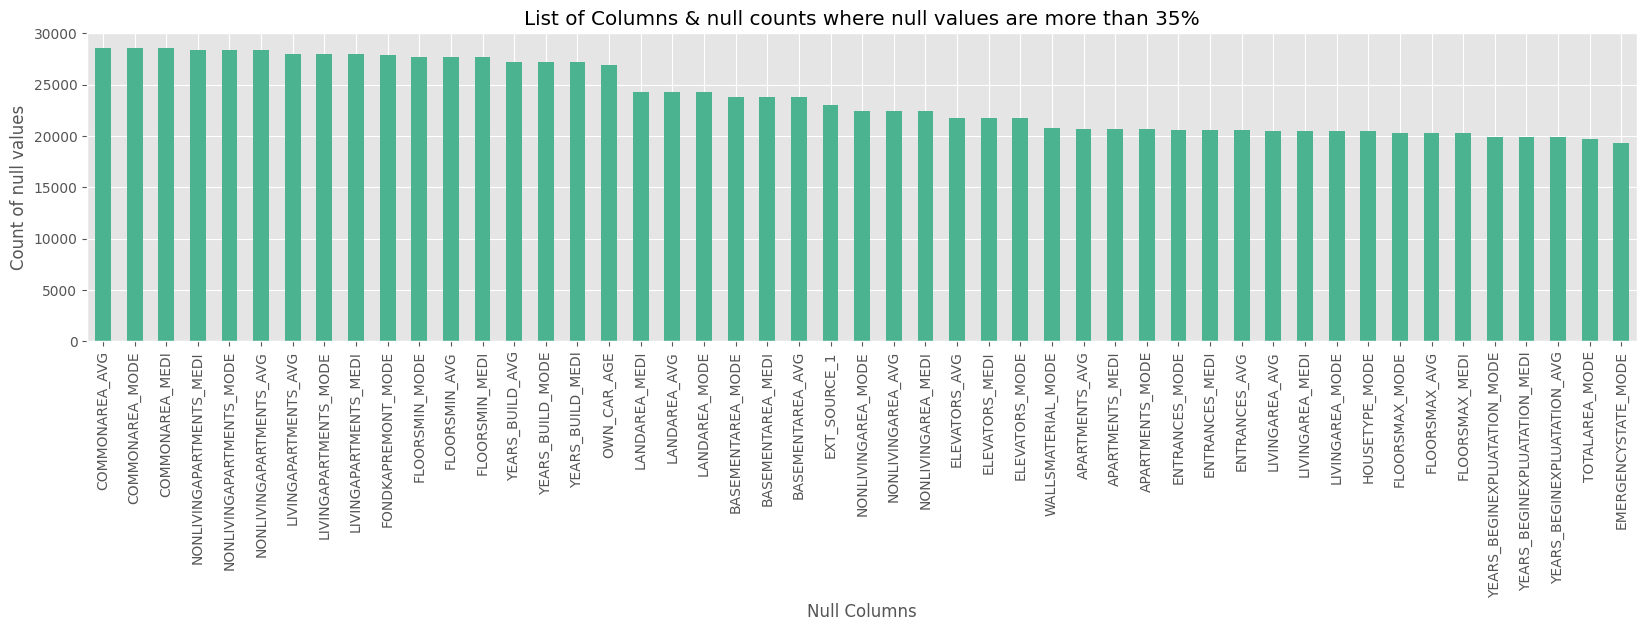

In [ ]:
null_col = df1.isnull().sum().sort_values(ascending = False)
null_col = null_col[null_col.values >(0.35*len(df1))]


#Plotting Bar Graph for null values greater than 35%

plt.figure(figsize=(20,4))
null_col.plot(kind='bar', color="#4CB391")
plt.title('List of Columns & null counts where null values are more than 35%')

plt.xlabel("Null Columns",fontdict={"fontsize":12,"fontweight":5})                  #Setting X-label and Y-label
plt.ylabel("Count of null values",fontdict={"fontsize":12,"fontweight":5})
plt.show()

In [ ]:
len(null_col)

49

In [ ]:
label = list(null_col.index.values) #Making list of column names having null values greater than 35%
df1.drop(labels = label,axis=1,inplace = True) #Droping those columns
df1.shape

(40782, 73)

In [ ]:
null = (df1.isnull().sum()/len(df1)*100).sort_values(ascending = False).head(50)
null.head(30)

,0
OCCUPATION_TYPE,31.410917
EXT_SOURCE_3,19.834731
AMT_REQ_CREDIT_BUREAU_YEAR,13.491246
AMT_REQ_CREDIT_BUREAU_QRT,13.491246
AMT_REQ_CREDIT_BUREAU_HOUR,13.491246
AMT_REQ_CREDIT_BUREAU_MON,13.491246
AMT_REQ_CREDIT_BUREAU_WEEK,13.491246
AMT_REQ_CREDIT_BUREAU_DAY,13.491246
NAME_TYPE_SUITE,0.384974
DEF_30_CNT_SOCIAL_CIRCLE,0.340837


In [ ]:
df1.AMT_REQ_CREDIT_BUREAU_YEAR.fillna(df1.AMT_REQ_CREDIT_BUREAU_YEAR.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_YEAR

df1.AMT_REQ_CREDIT_BUREAU_MON.fillna(df1.AMT_REQ_CREDIT_BUREAU_MON.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_MON

df1.AMT_REQ_CREDIT_BUREAU_WEEK.fillna(df1.AMT_REQ_CREDIT_BUREAU_WEEK.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_WEEK

df1.AMT_REQ_CREDIT_BUREAU_DAY.fillna(df1.AMT_REQ_CREDIT_BUREAU_DAY.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_DAY

df1.AMT_REQ_CREDIT_BUREAU_HOUR.fillna(df1.AMT_REQ_CREDIT_BUREAU_HOUR.mode()[0],inplace = True) #AMT_REQ_CREDIT_BUREAU_HOUR

df1.AMT_REQ_CREDIT_BUREAU_QRT.fillna(df1.AMT_REQ_CREDIT_BUREAU_QRT.mode()[0],inplace = True)   #AMT_REQ_CREDIT_BUREAU_QRT

df1.NAME_TYPE_SUITE.fillna(df1.NAME_TYPE_SUITE.mode()[0],inplace = True) #NAME_TYPE_SUITE

df1.OBS_30_CNT_SOCIAL_CIRCLE.fillna( df1.OBS_30_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #OBS_30_CNT_SOCIAL_CIRCLE

df1.DEF_30_CNT_SOCIAL_CIRCLE.fillna( df1.DEF_30_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #DEF_30_CNT_SOCIAL_CIRCLE

df1.OBS_60_CNT_SOCIAL_CIRCLE.fillna( df1.OBS_60_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #OBS_60_CNT_SOCIAL_CIRCLE

df1.DEF_60_CNT_SOCIAL_CIRCLE.fillna( df1.DEF_60_CNT_SOCIAL_CIRCLE.mode()[0],inplace = True) #DEF_60_CNT_SOCIAL_CIRCLE

df1.CNT_FAM_MEMBERS.fillna(df1.CNT_FAM_MEMBERS.mode() , inplace = True) #CNT_FAM_MEMBERS

df1.DAYS_LAST_PHONE_CHANGE.fillna(df1.DAYS_LAST_PHONE_CHANGE.mode()[0],inplace = True) #DAYS_LAST_PHONE_CHANGE

df1.EXT_SOURCE_2.fillna(df1.EXT_SOURCE_2.median() , inplace = True) #EXT_SOURCE_2

df1.EXT_SOURCE_3.fillna(df1.EXT_SOURCE_3.median() , inplace = True) #EXT_SOURCE_3

In [ ]:
(df1.isnull().sum()/len(df1)*100).sort_values(ascending=False)

,0
OCCUPATION_TYPE,31.410917
AMT_GOODS_PRICE,0.076014
REG_REGION_NOT_WORK_REGION,0.002452
FLAG_CONT_MOBILE,0.002452
FLAG_MOBIL,0.002452
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.000000
AMT_REQ_CREDIT_BUREAU_WEEK,0.000000
AMT_REQ_CREDIT_BUREAU_MON,0.000000
AMT_REQ_CREDIT_BUREAU_QRT,0.000000


In [ ]:
df1[["DAYS_BIRTH","DAYS_EMPLOYED","DAYS_REGISTRATION","DAYS_ID_PUBLISH","DAYS_LAST_PHONE_CHANGE"]]

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
0,-9461,-637,-3648.0,-2120.0,-1134.0
1,-16765,-1188,-1186.0,-291.0,-828.0
2,-19046,-225,-4260.0,-2531.0,-815.0
3,-19005,-3039,-9833.0,-2437.0,-617.0
4,-19932,-3038,-4311.0,-3458.0,-1106.0
...,...,...,...,...,...
40777,-8639,-1650,-1485.0,-140.0,0.0
40778,-18602,-3422,-10108.0,-1260.0,-530.0
40779,-19399,-661,-6091.0,-2755.0,-670.0
40780,-10893,-3302,-163.0,-144.0,-1289.0


In [ ]:
day_cols = [i for i in df1 if i.startswith('DAYS')]
day_cols

['DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'DAYS_LAST_PHONE_CHANGE']

In [ ]:
df1[day_cols]= abs(df1[day_cols])
print(df1['DAYS_BIRTH'].unique())
print(df1['DAYS_EMPLOYED'].unique())
print(df1['DAYS_REGISTRATION'].unique())
print(df1['DAYS_ID_PUBLISH'].unique())
print(df1['DAYS_LAST_PHONE_CHANGE'].unique())

[ 9461 16765 19046 ... 13371 22100 16876]
[  637  1188   225 ... 11538  8377  8538]
[ 3648.  1186.  4260. ... 12834. 11015.  4315.]
[2120.  291. 2531. ... 5367. 5581.   nan]
[1134.  828.  815. ... 3607. 2723. 2796.]


In [ ]:
df1["FLAG_OWN_CAR"].value_counts()

,count
FLAG_OWN_CAR,
N,26874
Y,13908


In [ ]:
df1["CODE_GENDER"].value_counts()

,count
CODE_GENDER,
F,26823
M,13957
XNA,2


In [ ]:
df1['FLAG_OWN_CAR'] = np.where(df1['FLAG_OWN_CAR']=='Y', 1 , 0)
df1['FLAG_OWN_REALTY'] = np.where(df1['FLAG_OWN_REALTY']=='Y', 1 , 0)

In [ ]:
# Occupation = ["Farmer","Farmeer","Faarmer","IT Professional","Manager", "Clerk","Teacher","Business"] -> C

In [ ]:
df1[['FLAG_OWN_CAR','FLAG_OWN_REALTY']].head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY
0,0,1
1,0,0
2,1,1
3,0,1
4,0,1


In [ ]:
df1.CODE_GENDER.value_counts()
df1.loc[df1.CODE_GENDER == 'XNA','CODE_GENDER'] = 'F'
df1.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,26825
M,13957


In [ ]:
df1.ORGANIZATION_TYPE.value_counts().head()

,count
ORGANIZATION_TYPE,
Business Entity Type 3,8960
XNA,7332
Self-employed,5119
Other,2229
Medicine,1506


In [ ]:
df1[['ORGANIZATION_TYPE','NAME_INCOME_TYPE']].head(30)

,ORGANIZATION_TYPE,NAME_INCOME_TYPE
0,Business Entity Type 3,Working
1,School,State servant
2,Government,Working
3,Business Entity Type 3,Working
4,Religion,Working
5,Other,State servant
6,Business Entity Type 3,Commercial associate
7,Other,State servant
8,XNA,Pensioner
9,Electricity,Working


In [ ]:
df1.NAME_INCOME_TYPE.value_counts()    #Check the counts for each in NAME_INCOME_TYPE

,count
NAME_INCOME_TYPE,
Working,21230
Commercial associate,9333
Pensioner,7329
State servant,2881
Unemployed,5
Student,2
Businessman,2


In [ ]:
df1['ORGANIZATION_TYPE'] = df1['ORGANIZATION_TYPE'].replace('XNA', 'Pensioner')
df1['OCCUPATION_TYPE'].fillna('Pensioner' , inplace = True)

In [ ]:
df1['AMT_INCOME_TYPE'] = pd.qcut(df1.AMT_INCOME_TOTAL, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VERY_LOW', 'LOW', "MEDIUM", 'HIGH', 'VERY_HIGH'])
df1['AMT_INCOME_TYPE'].head(11)

,AMT_INCOME_TYPE
0,MEDIUM
1,HIGH
2,VERY_LOW
3,LOW
4,LOW
5,VERY_LOW
6,MEDIUM
7,VERY_HIGH
8,LOW
9,LOW


In [ ]:
df1['AMT_CREDIT_TYPE'] = pd.qcut(df1.AMT_CREDIT, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VERY_LOW', 'LOW', "MEDIUM", 'HIGH', 'VERY_HIGH'])
df1['AMT_CREDIT_TYPE'].head(11)


,AMT_CREDIT_TYPE
0,LOW
1,HIGH
2,VERY_LOW
3,LOW
4,LOW
5,LOW
6,VERY_HIGH
7,VERY_HIGH
8,HIGH
9,LOW


In [ ]:
df1['DAYS_BIRTH']= (df1['DAYS_BIRTH']/365).astype(int)    # Converting
df1['DAYS_BIRTH'].unique()
df1['AGE_GROUP']=pd.cut(df1['DAYS_BIRTH'],
                         bins=[19,25,35,60,100], labels=['Very_Young','Young', 'Middle_Age', 'Senior_Citizen'])   #Binning

df1[['DAYS_BIRTH','AGE_GROUP']].head()

,DAYS_BIRTH,AGE_GROUP
0,25,Very_Young
1,45,Middle_Age
2,52,Middle_Age
3,52,Middle_Age
4,54,Middle_Age


from matplotlib import pyplot as plt
_df_0['DAYS_BIRTH'].plot(kind='hist', bins=20, title='DAYS_BIRTH')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['DAYS_BIRTH']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'DAYS_BIRTH'}, axis=1)
              .sort_values('DAYS_BIRTH', ascending=True))
  xs = counted['DAYS_BIRTH']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('DAYS_BIRTH', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('DAYS_BIRTH')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_2['DAYS_BIRTH'].plot(kind='line', figsize=(8, 4), title='DAYS_BIRTH')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40782 entries, 0 to 40781
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   SK_ID_CURR                   40782 non-null  int64   
 1   TARGET                       40782 non-null  int64   
 2   NAME_CONTRACT_TYPE           40782 non-null  object  
 3   CODE_GENDER                  40782 non-null  object  
 4   FLAG_OWN_CAR                 40782 non-null  int64   
 5   FLAG_OWN_REALTY              40782 non-null  int64   
 6   CNT_CHILDREN                 40782 non-null  int64   
 7   AMT_INCOME_TOTAL             40782 non-null  float64 
 8   AMT_CREDIT                   40782 non-null  float64 
 9   AMT_ANNUITY                  40782 non-null  float64 
 10  AMT_GOODS_PRICE              40751 non-null  float64 
 11  NAME_TYPE_SUITE              40782 non-null  object  
 12  NAME_INCOME_TYPE             40782 non-null  object  
 13  N

In [ ]:
unwanted=['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','FLAG_EMAIL', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3','FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
       'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9','FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
       'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15','FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']

df1.drop(labels=unwanted,axis=1,inplace=True)

In [ ]:
numerical_col = df1.select_dtypes(include='number').columns
len(numerical_col)

35

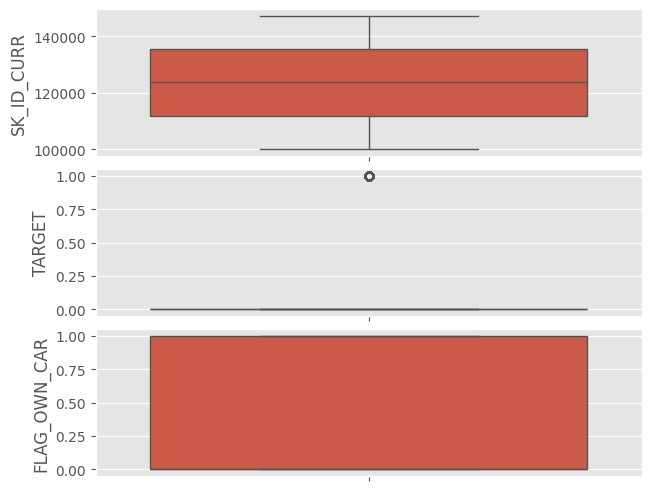

In [ ]:
fig , axes = plt.subplots(nrows=3, ncols=1, constrained_layout=True)                 # Plot Configuration
fig.subplots_adjust(left= 0, bottom=0, right=3, top=12, wspace=0.09, hspace=0.3)


for ax, column in zip(axes.flatten(),numerical_col):        #Using For loop

    sns.boxplot(df1[column],ax=ax)   #Ploting

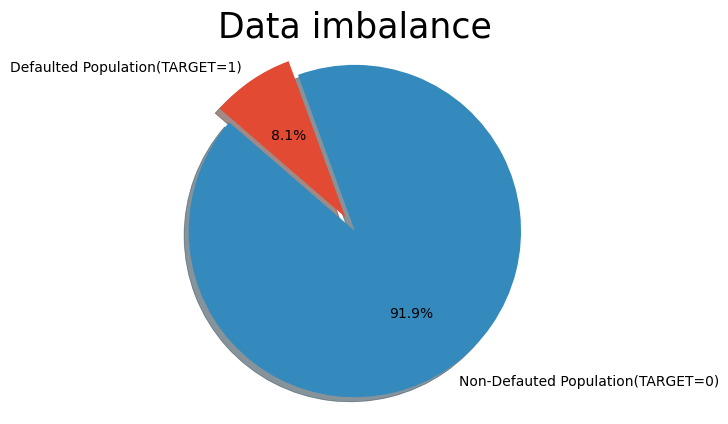

In [ ]:
count1 = 0
count0 = 0
for i in df1['TARGET'].values:
    if i == 1:
        count1 += 1
    else:
        count0 += 1

count1 = (count1/len(df1['TARGET']))*100
count0 = (count0/len(df1['TARGET']))*100

x = ['Defaulted Population(TARGET=1)','Non-Defauted Population(TARGET=0)']
y = [count1, count0]

explode = (0.1, 0)  # only "explode" the 1st slice

fig1, ax1 = plt.subplots()
ax1.pie(y, explode=explode, labels=x, autopct='%1.1f%%',
        shadow=True, startangle=110)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data imbalance',fontsize=25)
plt.show()

In [ ]:
# Separate the data based on the TARGET variable
Target0 = df1[df1['TARGET'] == 0]  # Non-defaulters (no payment difficulties)
Target1 = df1[df1['TARGET'] == 1]  # Defaulters (payment difficulties)

# Optional: Check the shapes to verify the split
print(f"Target 0 shape: {Target0.shape}")
print(f"Target 1 shape: {Target1.shape}")
print(f"\nTarget 0 percentage: {(len(Target0)/len(df1))*100:.2f}%")
print(f"Target 1 percentage: {(len(Target1)/len(df1))*100:.2f}%")

Target 0 shape: (37483, 48)
Target 1 shape: (3299, 48)

Target 0 percentage: 91.91%
Target 1 percentage: 8.09%


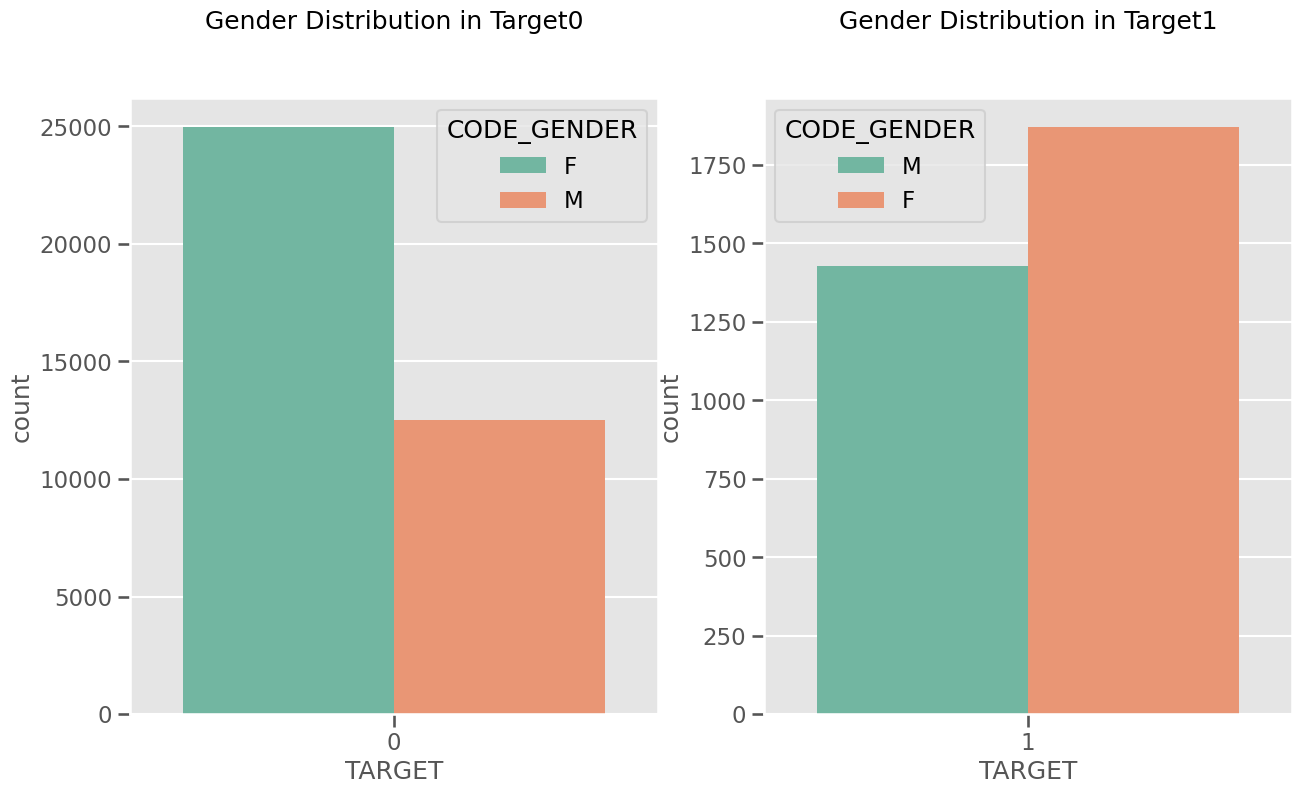

In [ ]:
plt.figure(figsize=(15,8))
plt.subplot(121)
sns.countplot(x='TARGET',hue='CODE_GENDER',data=Target0, palette = 'Set2')
plt.title("Gender Distribution in Target0")
plt.subplot(122)
sns.countplot(x='TARGET',hue='CODE_GENDER',data=Target1, palette = 'Set2')
plt.title("Gender Distribution in Target1")

plt.show()

<Figure size 4000x500 with 0 Axes>

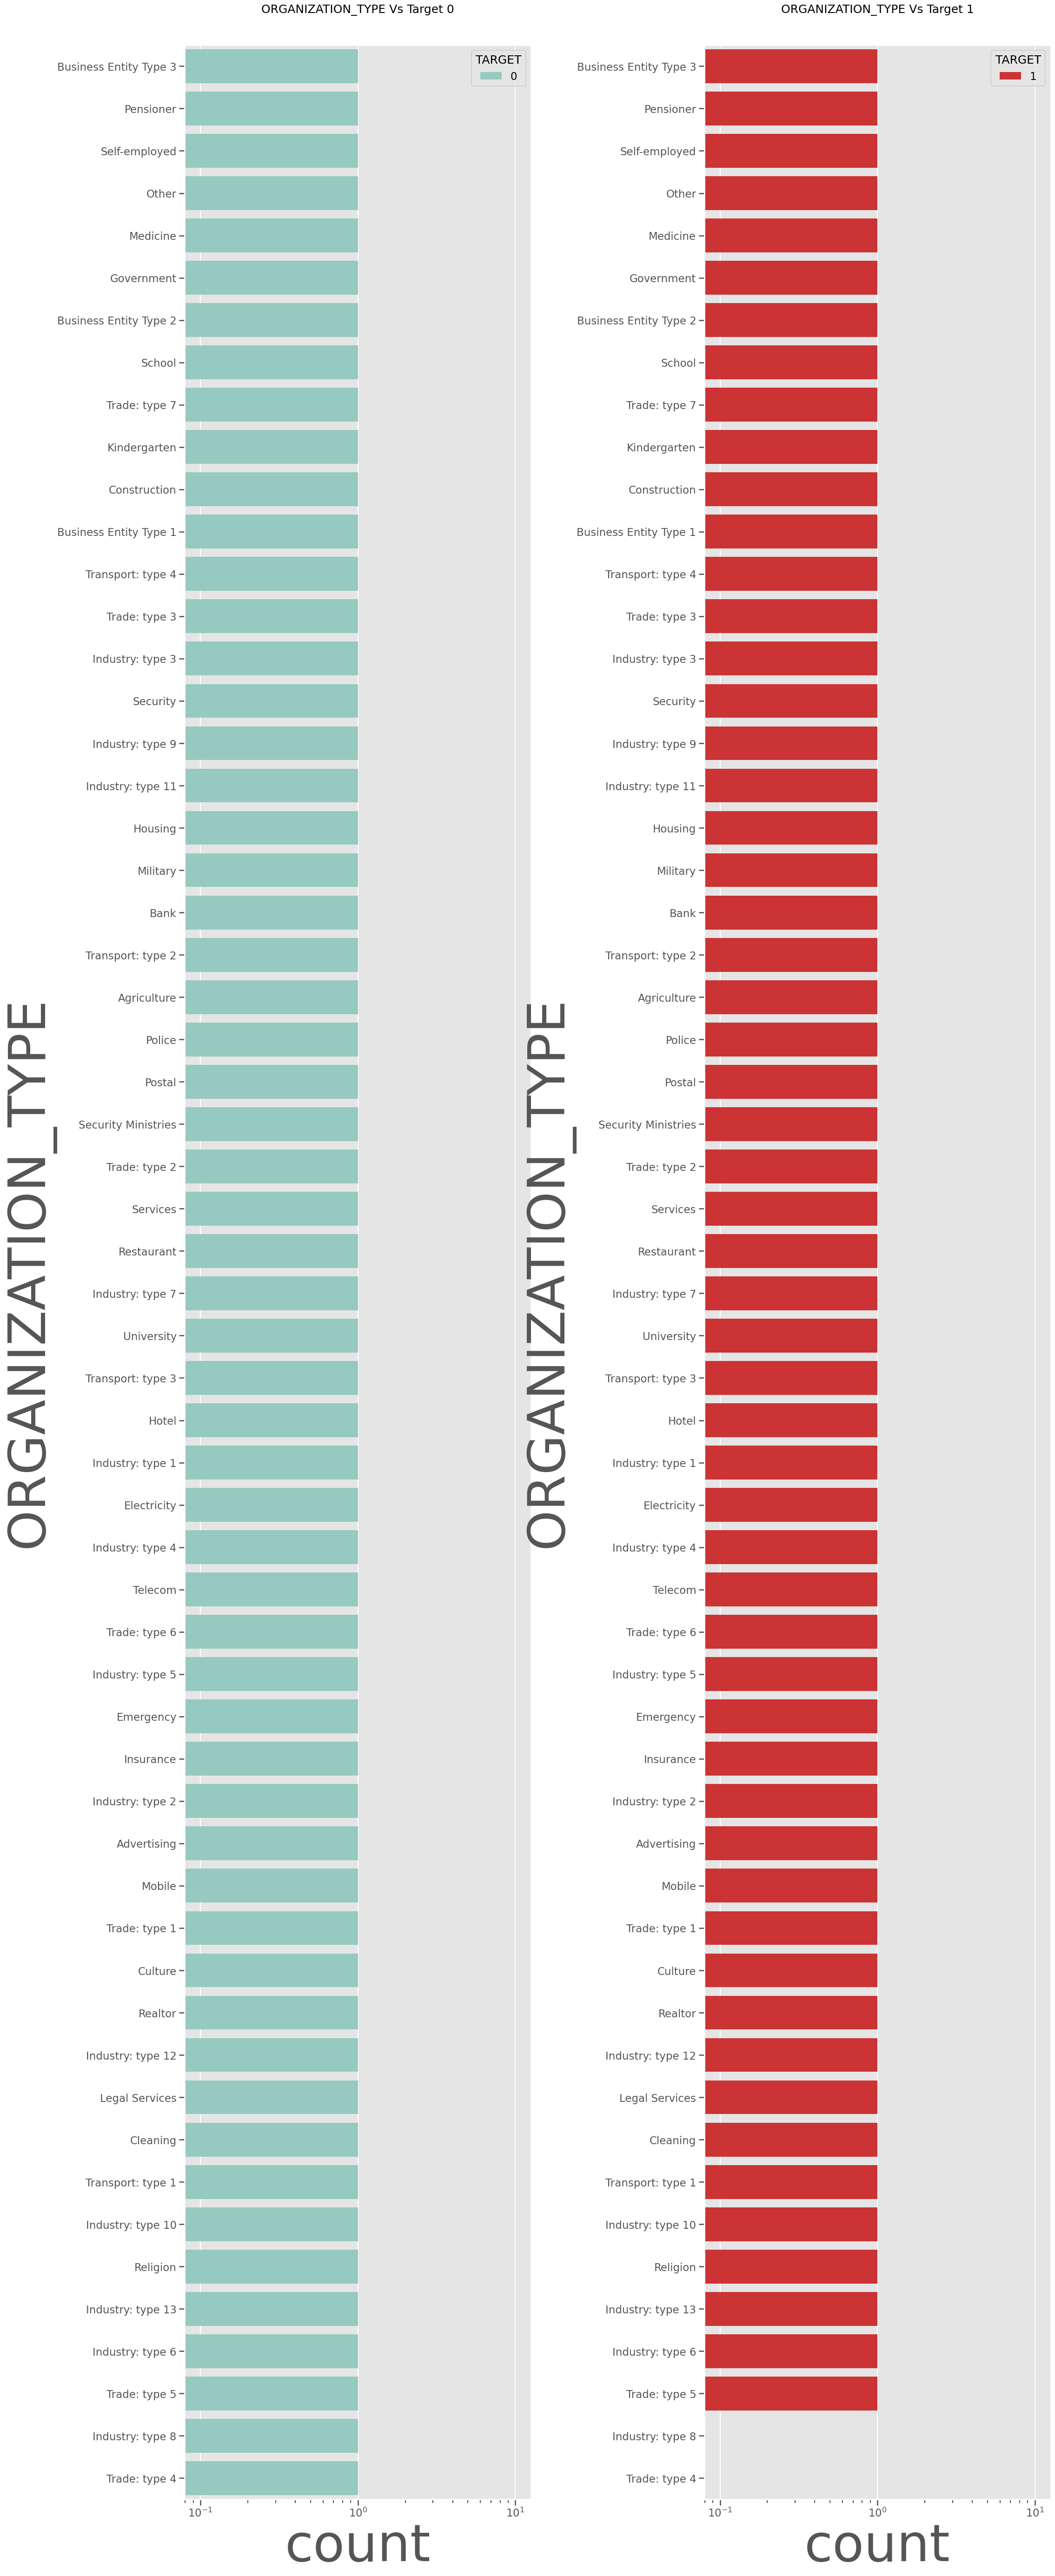

In [ ]:
plt.figure(figsize=(40,5))
plt.rcParams["axes.labelsize"] = 80
plt.rcParams['axes.titlesize'] = 80                                                           # Plot Configuration
plt.rcParams['axes.titlepad'] = 50
fig, axes = plt.subplots(nrows=1,ncols=2)
sns.set_context('talk')
fig.subplots_adjust(left= 0.09,bottom=1,right=3,top= 12,wspace=0.5,hspace=0.3)


plt.subplot(121)
plt.xscale('log')                                                                             # For Target0
sns.countplot(data=Target0,y='ORGANIZATION_TYPE',
              order=df1['ORGANIZATION_TYPE'].value_counts().index,palette='Set3',hue = 'TARGET')
plt.title("ORGANIZATION_TYPE Vs Target 0")



plt.subplot(122)
plt.xscale('log')                                                                              # For Target1
sns.countplot(data=Target1,y='ORGANIZATION_TYPE',
              order=df1['ORGANIZATION_TYPE'].value_counts().index,palette='Set1',hue = 'TARGET')
plt.title("ORGANIZATION_TYPE Vs Target 1")



plt.show();

In [ ]:
def categorical_plot(var):
    plt.figure(figsize=(40,20))

    plt.rcParams['axes.labelpad'] = 50
    plt.subplot(1, 2, 1)
    sns.countplot(var, data=Target0, palette = 'Set3', hue='TARGET')
    plt.xlabel(var, fontsize= 30, fontweight="bold")                                                         #Target 0
    plt.ylabel('Non Payment Difficulties', fontsize= 30, fontweight="bold")
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)


    plt.rcParams['axes.labelpad'] = 50
    plt.subplot(1, 2, 2)
    sns.countplot(var, data=Target1, palette = 'Set1', hue='TARGET')                                           # Target 1
    plt.xlabel(var, fontsize= 30, fontweight="bold")
    plt.ylabel('Payments Difficulties', fontsize= 30, fontweight="bold")
    plt.xticks(rotation=90, fontsize=30)
    plt.yticks(rotation=360, fontsize=30)
    plt.show()

In [ ]:
categorical_col = list(df1.select_dtypes(include= 'category').columns)


# Removing 'ORGANIZATION_TYPE','CODE_GENDER','AGE_GROUP' because we have already taken up the isights from  above plots

categorical_col.remove('ORGANIZATION_TYPE')
categorical_col.remove('CODE_GENDER')
categorical_col.remove('AGE_GROUP')

categorical_col #Checking after removing columns

ValueError: list.remove(x): x not in list

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [64]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [65]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA) AND CLASSIFICATION")
print("Dataset: Wine Quality (UCI Machine Learning Repository)")
print("="*80)

EXPLORATORY DATA ANALYSIS (EDA) AND CLASSIFICATION
Dataset: Wine Quality (UCI Machine Learning Repository)


In [66]:
# ============================================================================
# 1. DATA LOADING
# ============================================================================
print("\n[1] LOADING DATA...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(f"\nDataset shape: {df.shape}")
print(f"Features: {df.shape[1]-1}, Samples: {df.shape[0]}")


[1] LOADING DATA...

Dataset shape: (1599, 12)
Features: 11, Samples: 1599


In [67]:

# ============================================================================
# 2. BASIC DATA EXPLORATION
# ============================================================================
print("\n" + "="*80)
print("[2] BASIC DATA EXPLORATION")
print("="*80)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())


[2] BASIC DATA EXPLORATION

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  


[3] UNIVARIATE ANALYSIS

Target Distribution (Good Wine: quality >= 6):
quality_binary
1    855
0    744
Name: count, dtype: int64
Percentage of Good Wine: 53.47%

✓ Univariate distribution plots saved as 'univariate_analysis.png'


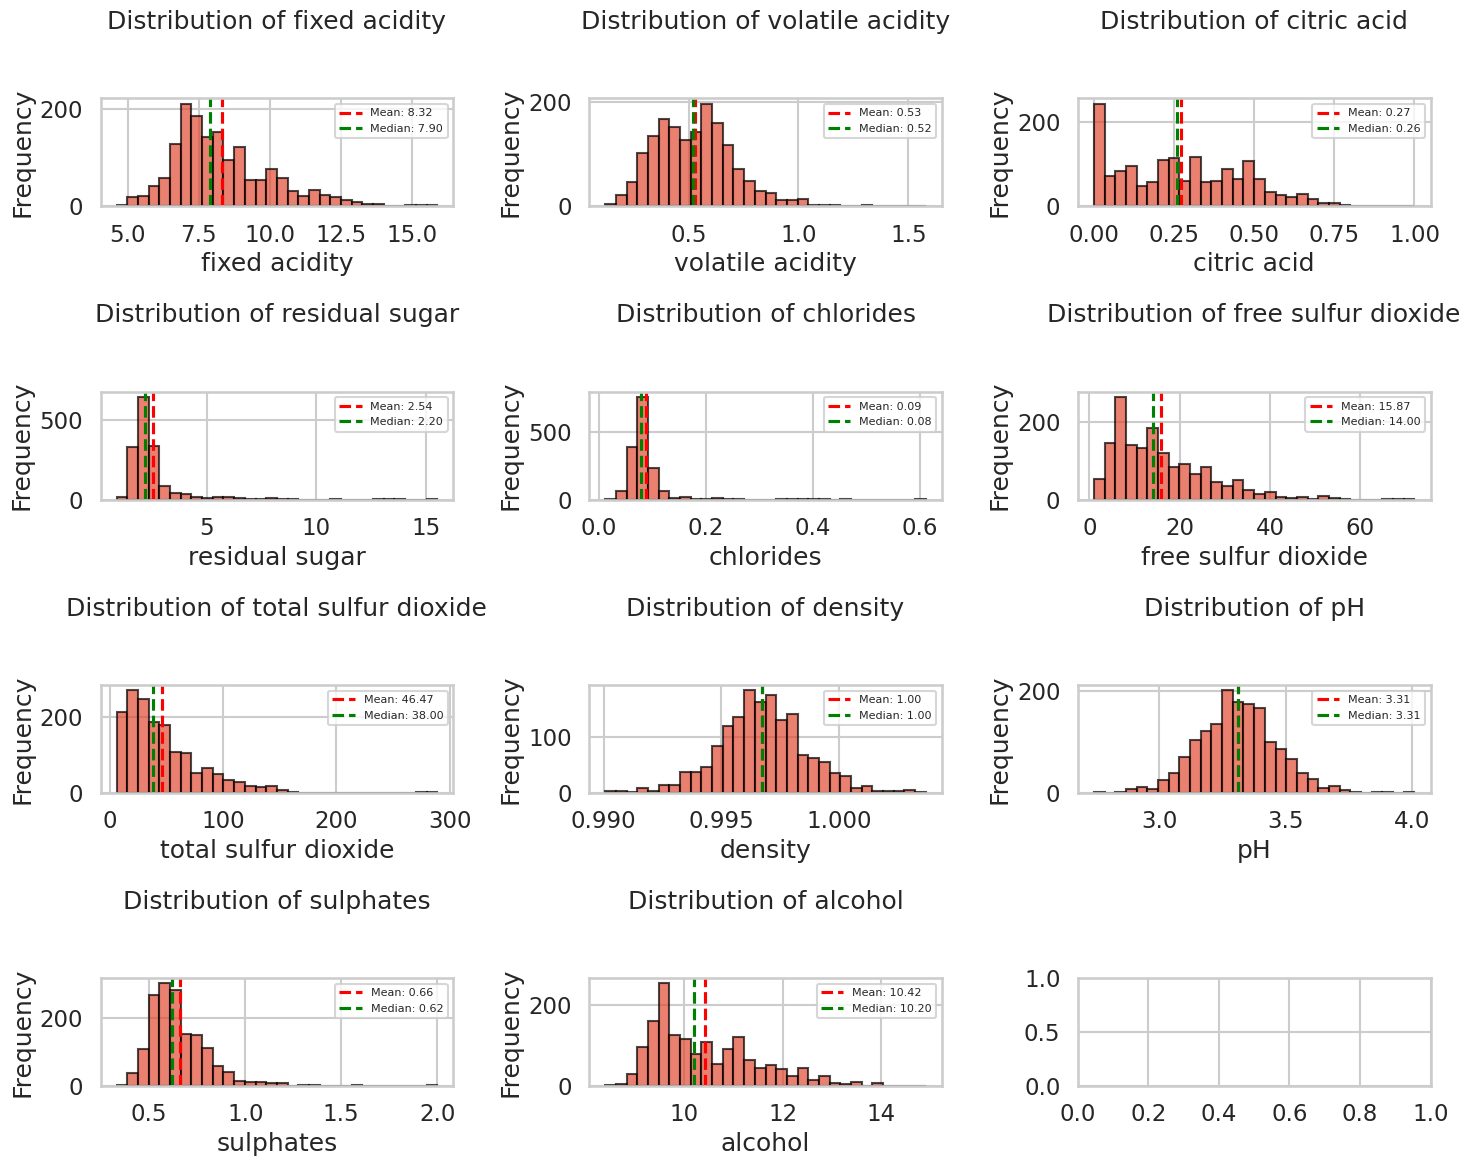

In [68]:
# ============================================================================
# 3. UNIVARIATE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("[3] UNIVARIATE ANALYSIS")
print("="*80)

# Create binary target for classification (quality >= 6 is "good")
df['quality_binary'] = (df['quality'] >= 6).astype(int)
print(f"\nTarget Distribution (Good Wine: quality >= 6):")
print(df['quality_binary'].value_counts())
print(f"Percentage of Good Wine: {df['quality_binary'].mean()*100:.2f}%")

# Numerical features
numerical_features = df.columns[:-2]  # Exclude 'quality' and 'quality_binary'

# Distribution plots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='g', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Univariate distribution plots saved as 'univariate_analysis.png'")


In [69]:
# Skewness and Kurtosis
print("\nSkewness and Kurtosis:")
skew_kurt = pd.DataFrame({
    'Feature': numerical_features,
    'Skewness': [df[col].skew() for col in numerical_features],
    'Kurtosis': [df[col].kurtosis() for col in numerical_features]
})
print(skew_kurt)


Skewness and Kurtosis:
                 Feature  Skewness   Kurtosis
0          fixed acidity  0.982751   1.132143
1       volatile acidity  0.671593   1.225542
2            citric acid  0.318337  -0.788998
3         residual sugar  4.540655  28.617595
4              chlorides  5.680347  41.715787
5    free sulfur dioxide  1.250567   2.023562
6   total sulfur dioxide  1.515531   3.809824
7                density  0.071288   0.934079
8                     pH  0.193683   0.806943
9              sulphates  2.428672  11.720251
10               alcohol  0.860829   0.200029



[4] BIVARIATE ANALYSIS

Correlation with Target (quality_binary):
alcohol                 0.434751
sulphates               0.218072
citric acid             0.159129
fixed acidity           0.095093
residual sugar         -0.002160
pH                     -0.003264
free sulfur dioxide    -0.061757
chlorides              -0.109494
density                -0.159110
total sulfur dioxide   -0.231963
volatile acidity       -0.321441
dtype: float64

✓ Bivariate scatter plots saved as 'bivariate_analysis.png'


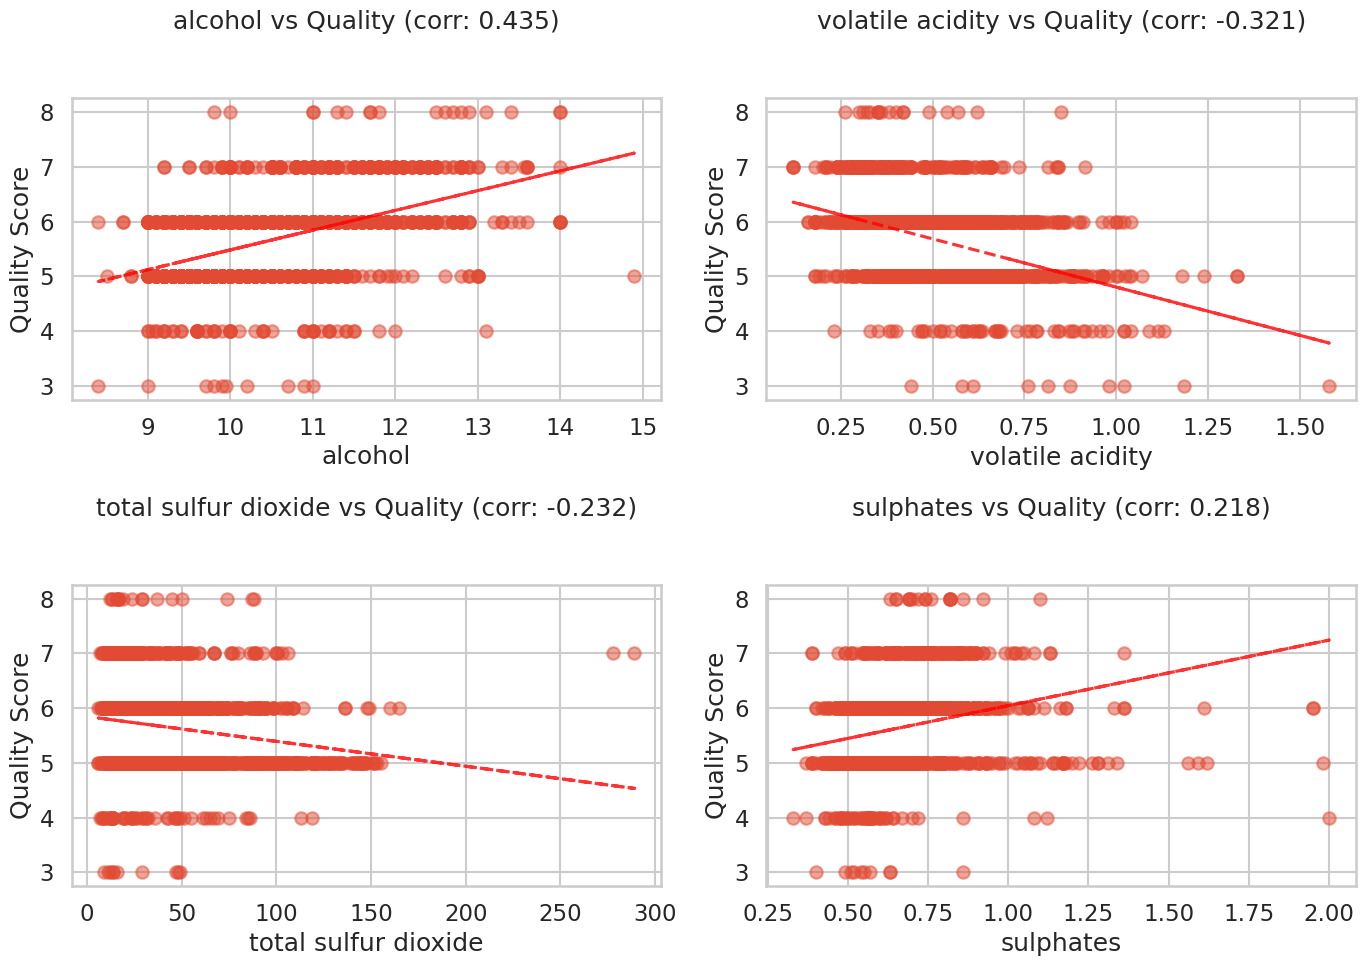

In [70]:
# ============================================================================
# 4. BIVARIATE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("[4] BIVARIATE ANALYSIS")
print("="*80)

# Correlation with target
print("\nCorrelation with Target (quality_binary):")
correlations = df[numerical_features].corrwith(df['quality_binary']).sort_values(ascending=False)
print(correlations)

# Scatter plots for top correlated features
top_features = correlations.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['quality'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Quality Score')
    axes[idx].set_title(f'{feature} vs Quality (corr: {correlations[feature]:.3f})')

    # Add regression line
    z = np.polyfit(df[feature], df['quality'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8)

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Bivariate scatter plots saved as 'bivariate_analysis.png'")

✓ Box plots saved as 'boxplot_bivariate.png'


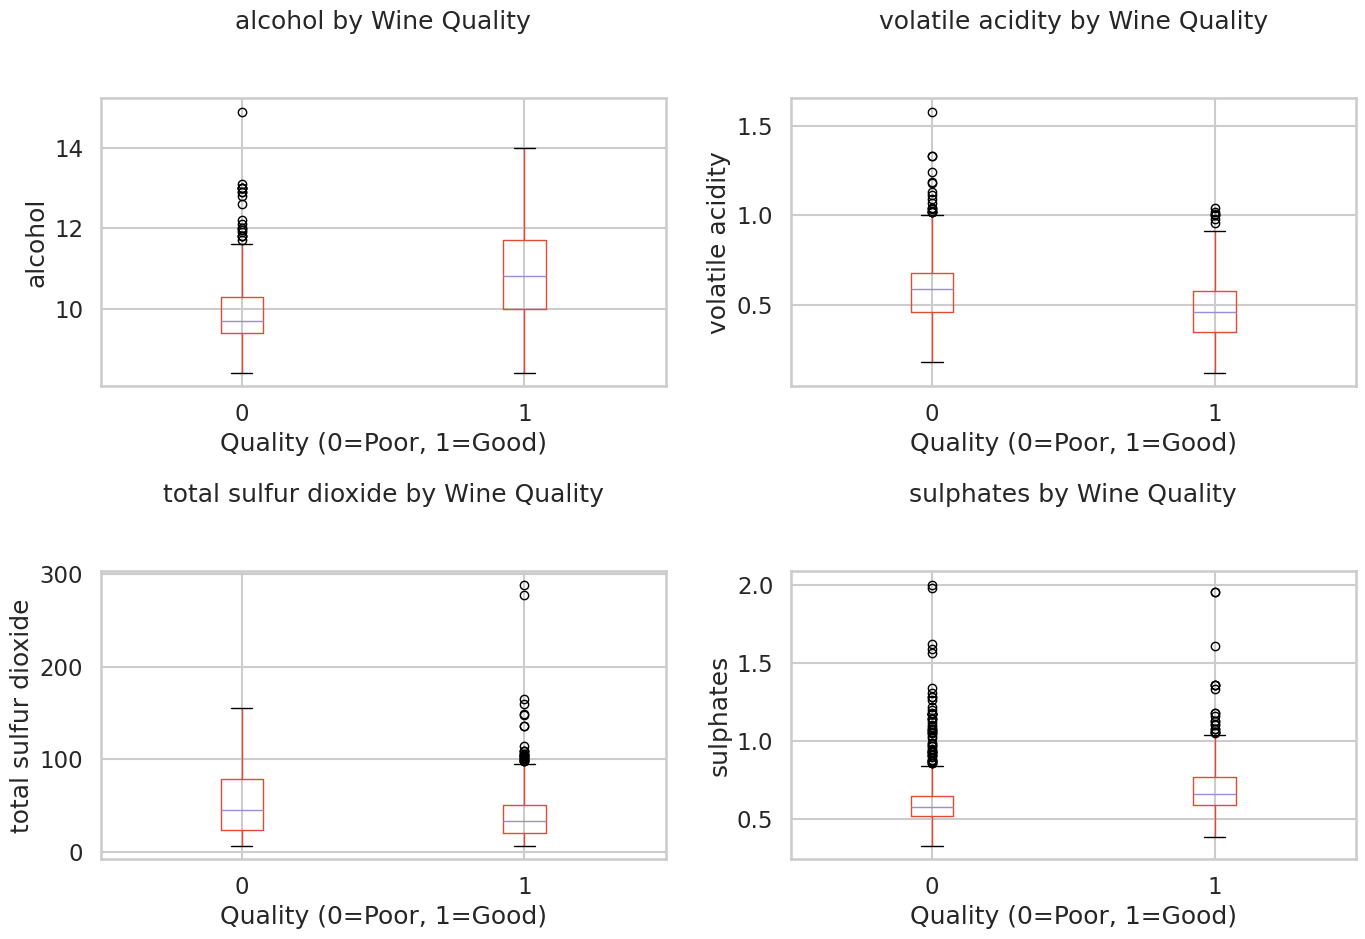

In [71]:
# Box plots by quality category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    df.boxplot(column=feature, by='quality_binary', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Wine Quality')
    axes[idx].set_xlabel('Quality (0=Poor, 1=Good)')
    axes[idx].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplot_bivariate.png', dpi=300, bbox_inches='tight')
print("✓ Box plots saved as 'boxplot_bivariate.png'")



[5] CORRELATION ANALYSIS

Correlation Matrix:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity               0.114777   0

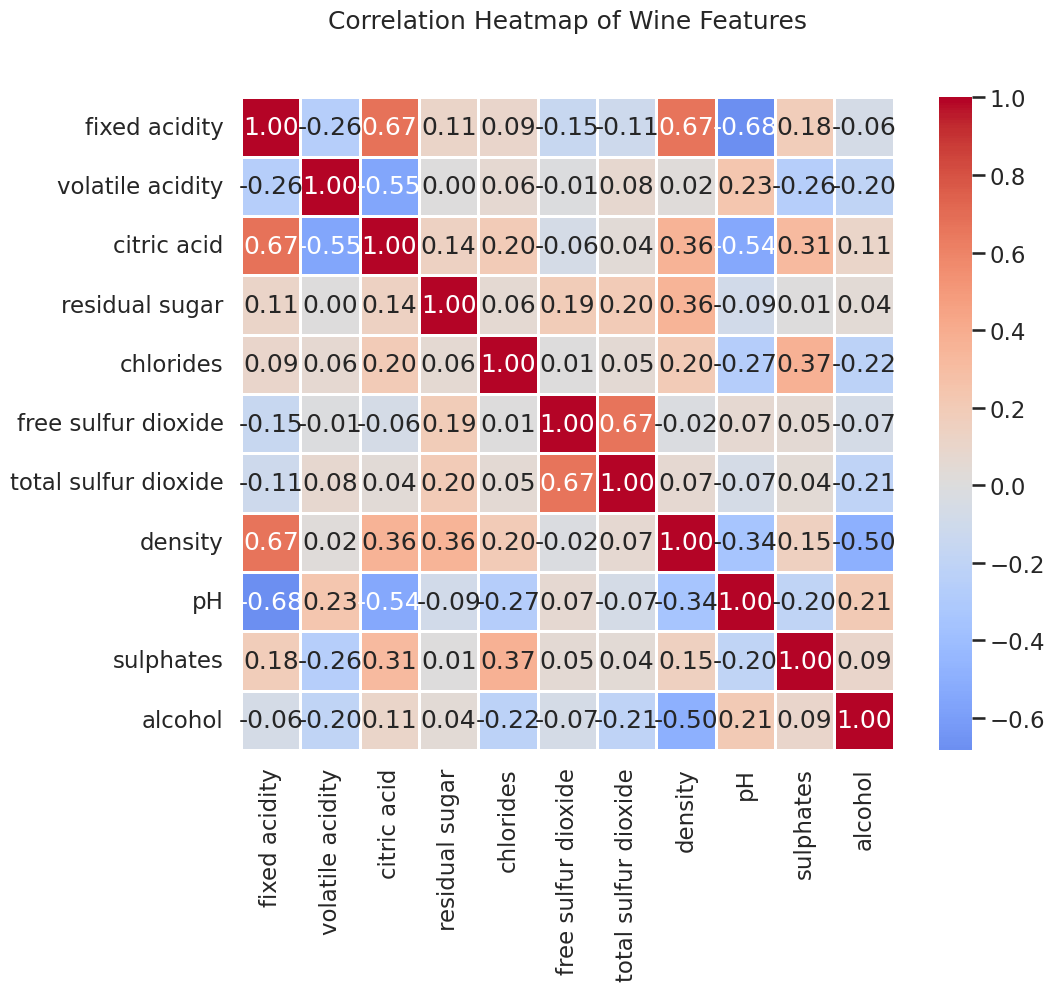

In [72]:
# ============================================================================
# 5. CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("[5] CORRELATION ANALYSIS")
print("="*80)

# Correlation matrix
correlation_matrix = df[numerical_features].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap of Wine Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Correlation heatmap saved as 'correlation_heatmap.png'")

# Highly correlated pairs
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append([correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]])
if high_corr:
    high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
    print(high_corr_df)
else:
    print("No feature pairs with correlation > 0.7")


[6] COVARIANCE ANALYSIS

Covariance Matrix:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              3.031416         -0.079851     0.227820   
volatile acidity          -0.079851          0.032062    -0.019272   
citric acid                0.227820         -0.019272     0.037947   
residual sugar             0.281756          0.000484     0.039434   
chlorides                  0.007679          0.000517     0.001869   
free sulfur dioxide       -2.800921         -0.019674    -0.124252   
total sulfur dioxide      -6.482346          0.450426     0.227697   
density                    0.002195          0.000007     0.000134   
pH                        -0.183586          0.006495    -0.016298   
sulphates                  0.054010         -0.007921     0.010328   
alcohol                   -0.114421         -0.038600     0.022815   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity               0.281756   0.0

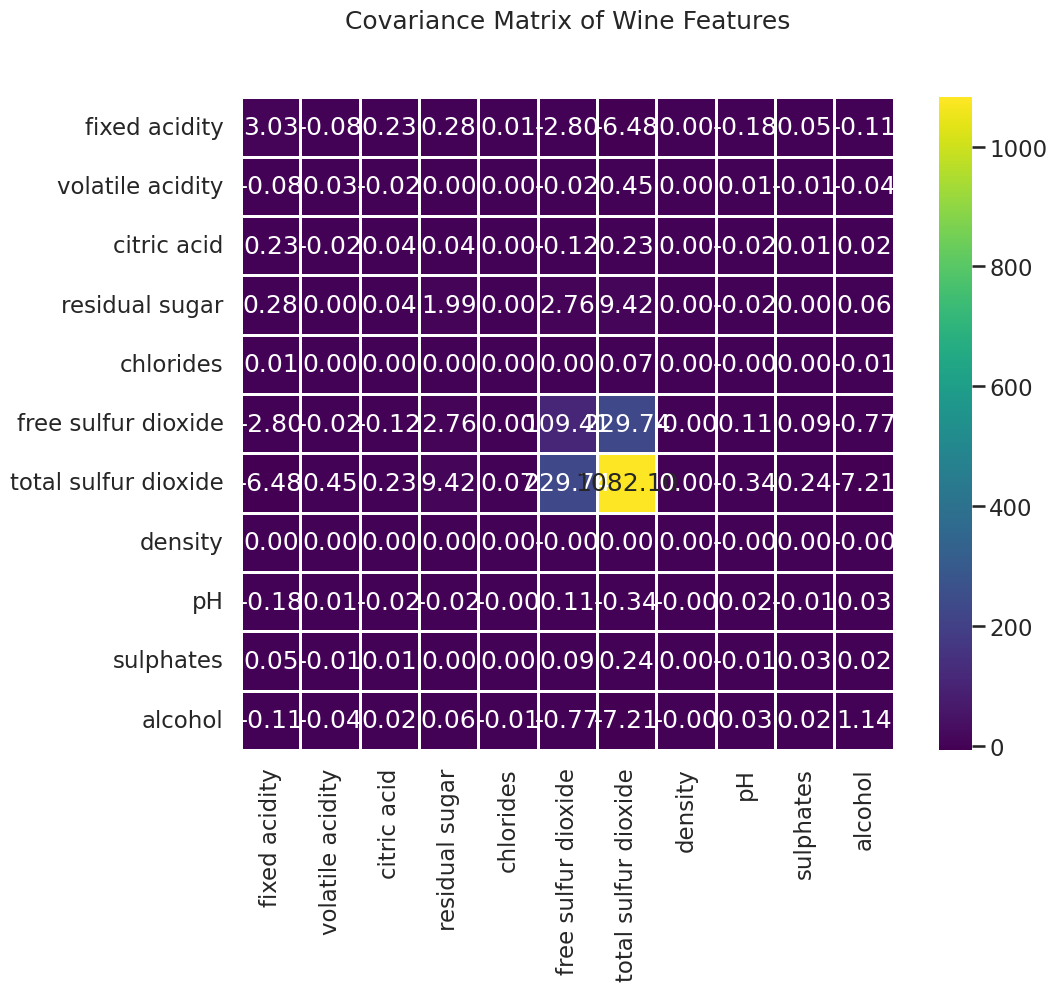

In [73]:
# ============================================================================
# 6. COVARIANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("[6] COVARIANCE ANALYSIS")
print("="*80)

# Covariance matrix
covariance_matrix = df[numerical_features].cov()
print("\nCovariance Matrix:")
print(covariance_matrix)

# Visualize covariance
plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, annot=True, fmt='.2f', cmap='viridis',
            square=True, linewidths=1)
plt.title('Covariance Matrix of Wine Features')
plt.tight_layout()
plt.savefig('covariance_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Covariance heatmap saved as 'covariance_heatmap.png'")


[7] MULTIVARIATE ANALYSIS

Creating pair plot for top 5 features: ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'sulphates', 'citric acid']
✓ Pair plot saved as 'pairplot_multivariate.png'
✓ 3D scatter plot saved as '3d_scatter.png'


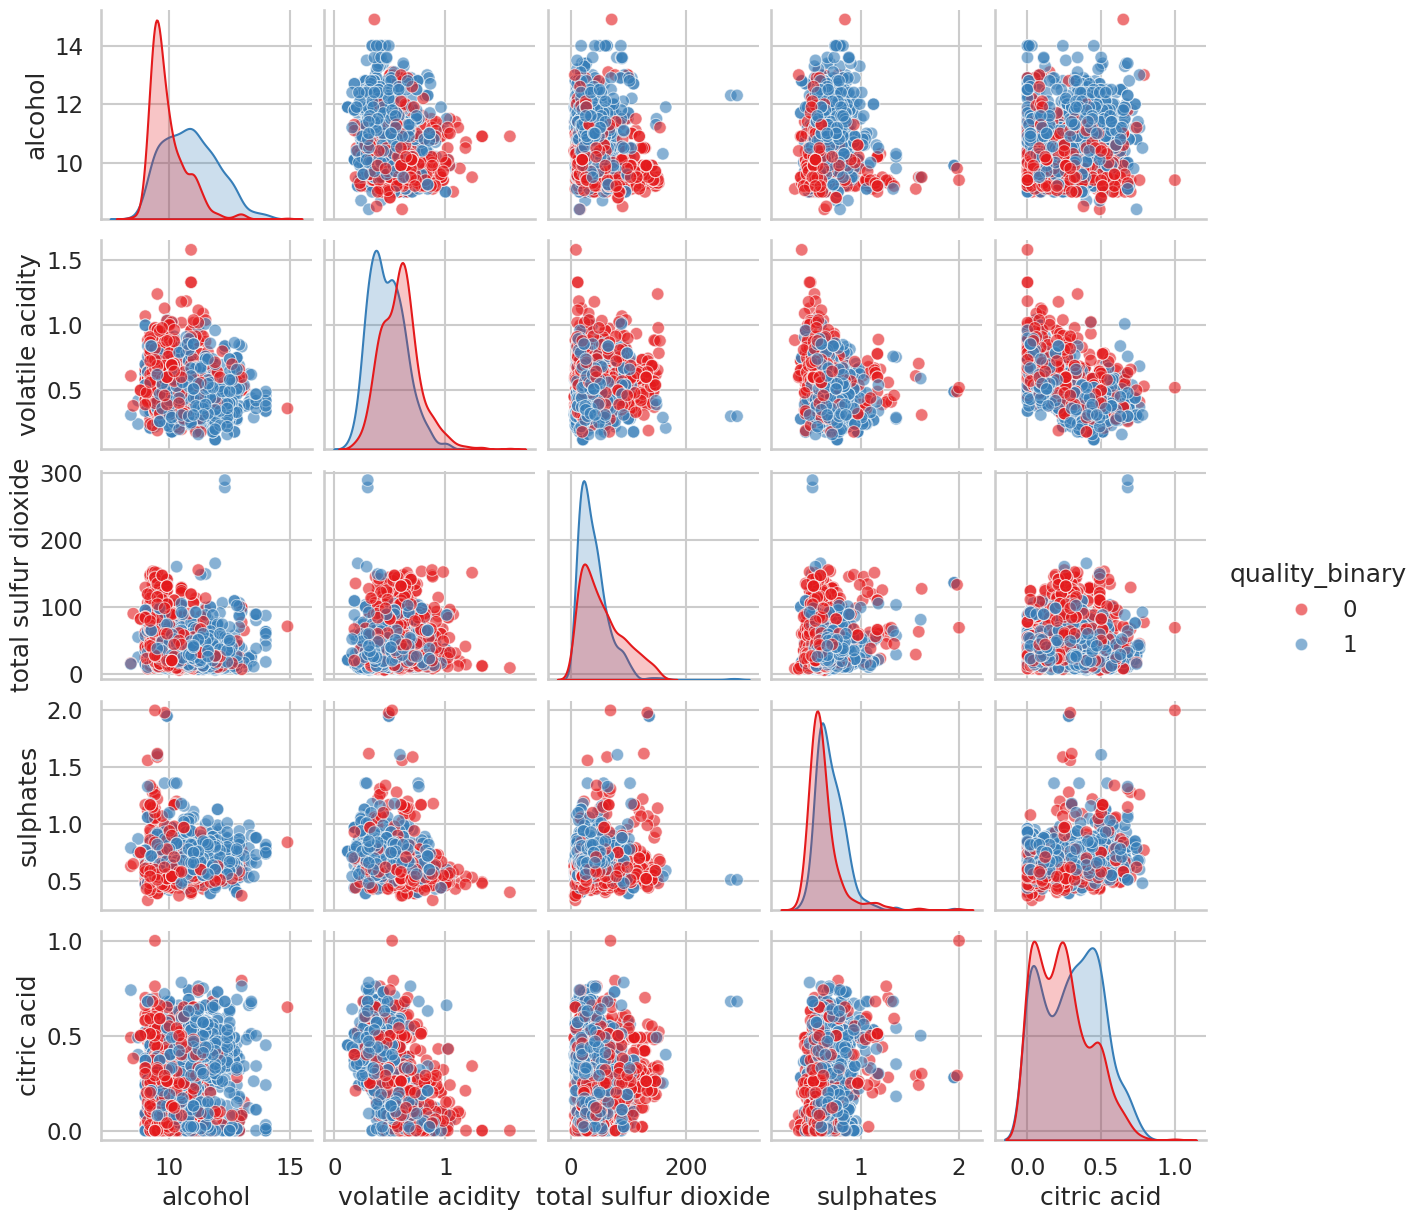

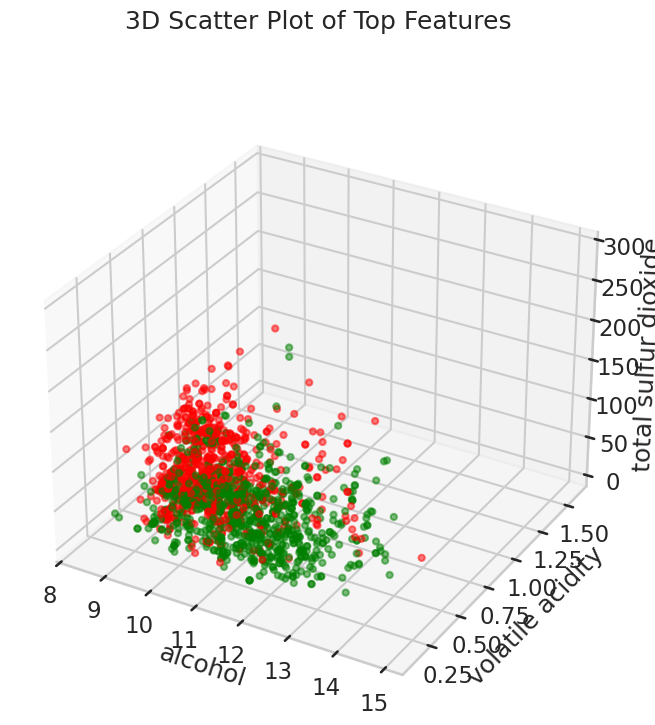

In [74]:
# ============================================================================
# 7. MULTIVARIATE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("[7] MULTIVARIATE ANALYSIS")
print("="*80)

# Pair plot for top 5 correlated features
top_5_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()
print(f"\nCreating pair plot for top 5 features: {top_5_features}")

pairplot_df = df[top_5_features + ['quality_binary']]
sns.pairplot(pairplot_df, hue='quality_binary', palette='Set1',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.savefig('pairplot_multivariate.png', dpi=300, bbox_inches='tight')
print("✓ Pair plot saved as 'pairplot_multivariate.png'")

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red' if x == 0 else 'green' for x in df['quality_binary']]
ax.scatter(df[top_5_features[0]], df[top_5_features[1]],
           df[top_5_features[2]], c=colors, alpha=0.5)

ax.set_xlabel(top_5_features[0])
ax.set_ylabel(top_5_features[1])
ax.set_zlabel(top_5_features[2])
ax.set_title('3D Scatter Plot of Top Features')
plt.savefig('3d_scatter.png', dpi=300, bbox_inches='tight')
print("✓ 3D scatter plot saved as '3d_scatter.png'")


[8] OUTLIER DETECTION AND REMOVAL

Original dataset size: 1599 rows

Outlier counts by feature:
residual sugar: 155 outliers (9.69%)
chlorides: 112 outliers (7.00%)
sulphates: 59 outliers (3.69%)
total sulfur dioxide: 55 outliers (3.44%)
fixed acidity: 49 outliers (3.06%)
density: 45 outliers (2.81%)
pH: 35 outliers (2.19%)
free sulfur dioxide: 30 outliers (1.88%)
volatile acidity: 19 outliers (1.19%)
alcohol: 13 outliers (0.81%)
citric acid: 1 outliers (0.06%)

Dataset size after outlier removal: 1135 rows
Removed 464 rows (29.02%)

✓ Outlier removal comparison saved as 'outlier_removal.png'


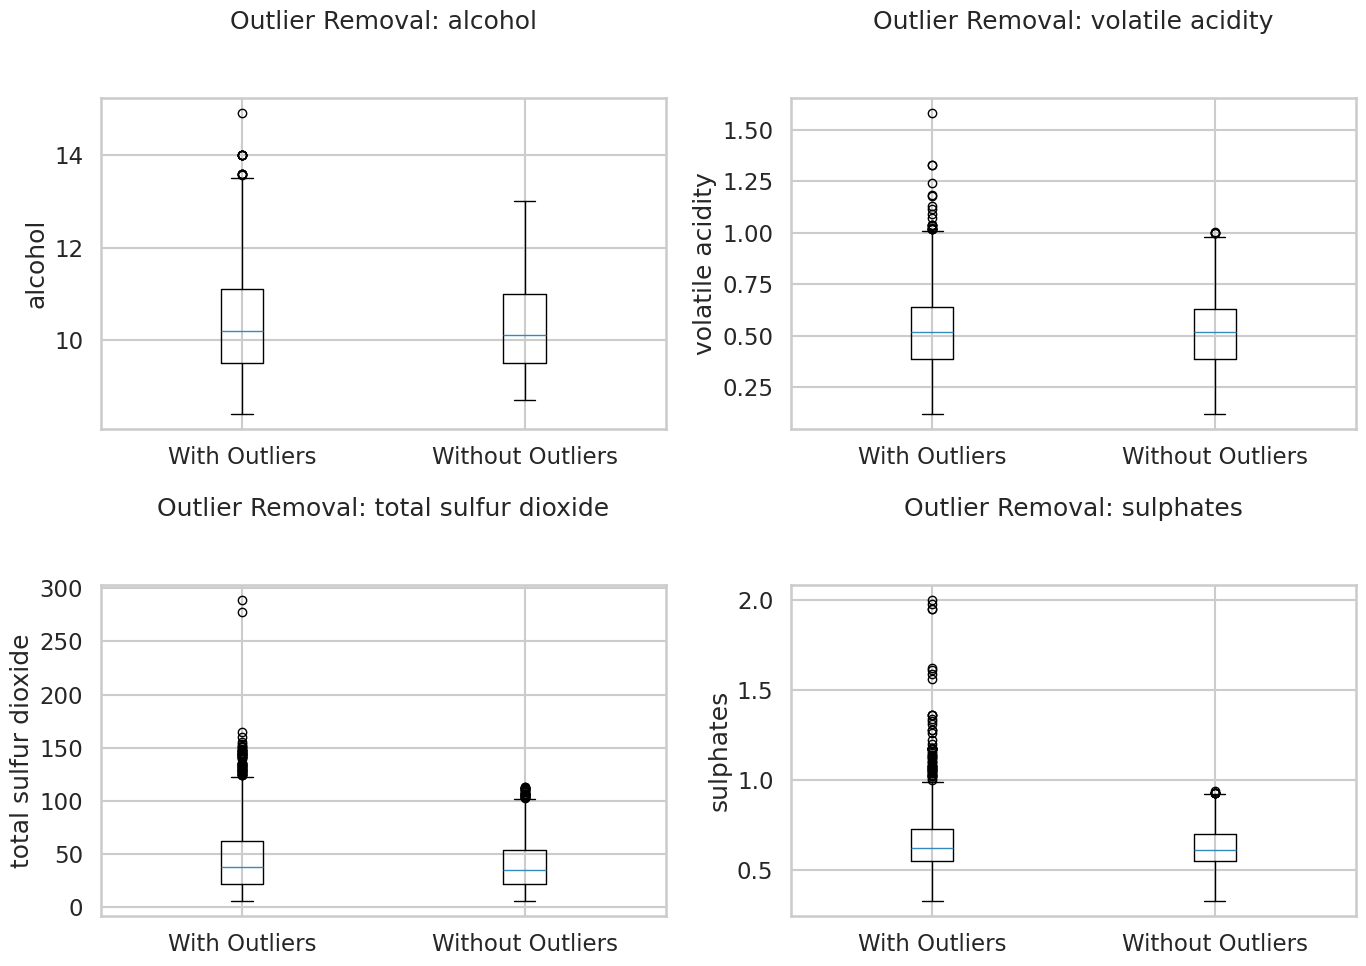

In [75]:
# ============================================================================
# 8. OUTLIER DETECTION AND REMOVAL
# ============================================================================
print("\n" + "="*80)
print("[8] OUTLIER DETECTION AND REMOVAL")
print("="*80)

print(f"\nOriginal dataset size: {df.shape[0]} rows")

# Detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

# Count outliers per feature
outlier_counts = {}
for col in numerical_features:
    outliers = detect_outliers_iqr(df, col)
    outlier_counts[col] = outliers.sum()

print("\nOutlier counts by feature:")
for feature, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {count} outliers ({count/len(df)*100:.2f}%)")

# Remove rows with outliers in any feature
df_no_outliers = df.copy()
for col in numerical_features:
    outliers = detect_outliers_iqr(df_no_outliers, col)
    df_no_outliers = df_no_outliers[~outliers]

print(f"\nDataset size after outlier removal: {df_no_outliers.shape[0]} rows")
print(f"Removed {df.shape[0] - df_no_outliers.shape[0]} rows ({(df.shape[0] - df_no_outliers.shape[0])/df.shape[0]*100:.2f}%)")

# Visualize before and after
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].boxplot([df[feature], df_no_outliers[feature]],
                       labels=['With Outliers', 'Without Outliers'])
    axes[idx].set_title(f'Outlier Removal: {feature}')
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=300, bbox_inches='tight')
print("\n✓ Outlier removal comparison saved as 'outlier_removal.png'")

In [76]:
# ============================================================================
# 9. LOGISTIC REGRESSION CLASSIFICATION
# ============================================================================
print("\n" + "="*80)
print("[9] LOGISTIC REGRESSION CLASSIFICATION")
print("="*80)

# Prepare data
X = df_no_outliers[numerical_features]
y = df_no_outliers['quality_binary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
print("\nTraining Logistic Regression model...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


[9] LOGISTIC REGRESSION CLASSIFICATION

Training set size: 908
Test set size: 227

Class distribution in training set:
quality_binary
1    0.538546
0    0.461454
Name: proportion, dtype: float64

Training Logistic Regression model...



[10] MODEL EVALUATION

Accuracy: 0.7445 (74.45%)

Classification Report:
               precision    recall  f1-score   support

Poor Wine (0)       0.70      0.77      0.74       105
Good Wine (1)       0.79      0.72      0.75       122

     accuracy                           0.74       227
    macro avg       0.75      0.75      0.74       227
 weighted avg       0.75      0.74      0.74       227


Confusion Matrix:
[[81 24]
 [34 88]]

✓ Confusion matrix saved as 'confusion_matrix.png'
✓ ROC curve saved as 'roc_curve.png'

ROC AUC Score: 0.8265

Feature Importance (Coefficients):
                 Feature  Coefficient
10               alcohol     0.945395
9              sulphates     0.657169
5    free sulfur dioxide     0.103085
7                density     0.095620
3         residual sugar    -0.044862
0          fixed acidity    -0.056037
4              chlorides    -0.089000
6   total sulfur dioxide    -0.186610
2            citric acid    -0.235301
8                     pH   

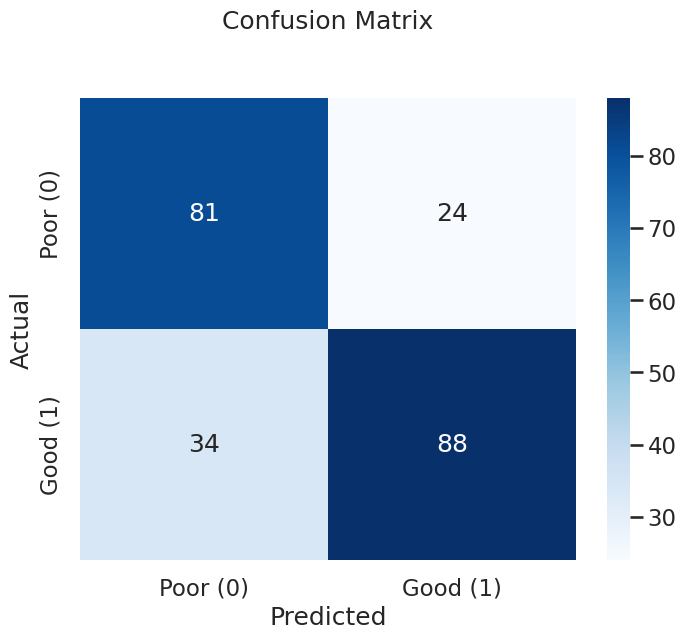

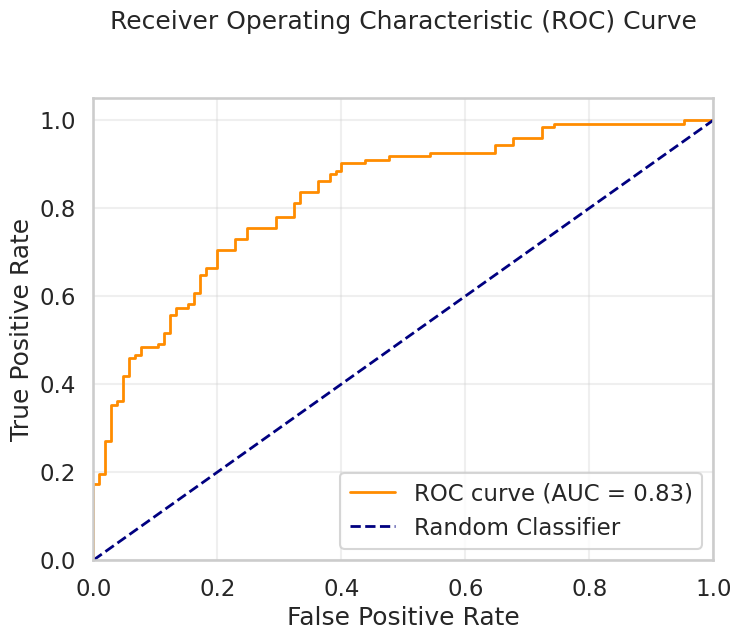

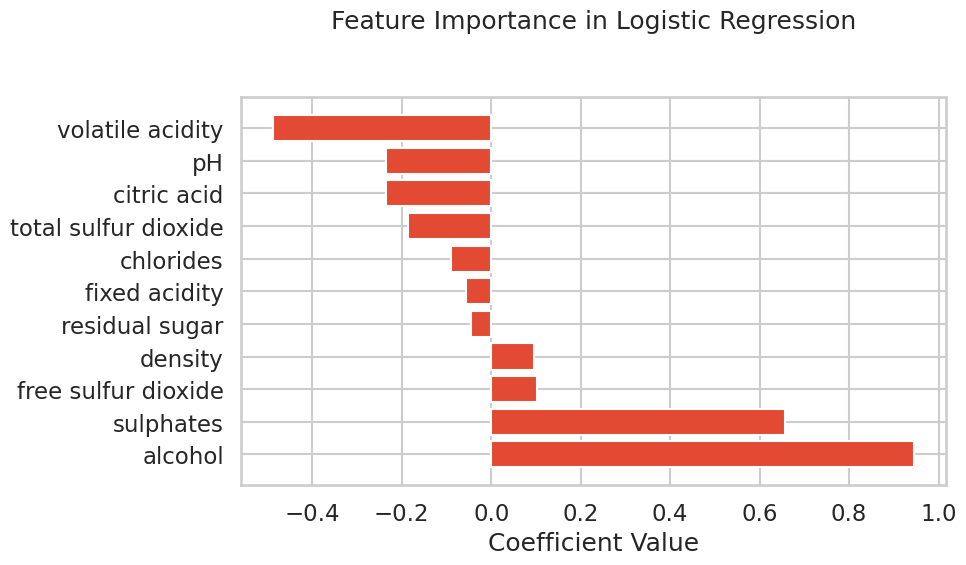

In [77]:
# ============================================================================
# 10. MODEL EVALUATION
# ============================================================================
print("\n" + "="*80)
print("[10] MODEL EVALUATION")
print("="*80)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Poor Wine (0)', 'Good Wine (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor (0)', 'Good (1)'],
            yticklabels=['Poor (0)', 'Good (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix saved as 'confusion_matrix.png'")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
print(f"✓ ROC curve saved as 'roc_curve.png'")
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': numerical_features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nFeature Importance (Coefficients):")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Feature importance plot saved as 'feature_importance.png'")